# ARIMA forecasting — `qufin.timeseries`

The **Box–Jenkins** ARIMA family is the classical toolkit for modelling a
single series through its own past. Three building blocks combine:

* **AR(p)** — *autoregression*: today is a weighted sum of recent values.
  Captures momentum and mean reversion.
* **MA(q)** — *moving average*: today is a weighted sum of recent **shocks**.
  Captures short-lived news effects.
* **I(d)** — *integration*: difference the series $d$ times to remove a
  stochastic trend (a unit root) before modelling.

$$ \underbrace{\Big(1-\textstyle\sum_{i=1}^p\phi_i L^i\Big)}_{\text{AR}}\,(1-L)^d y_t = \underbrace{\Big(1+\textstyle\sum_{j=1}^q\theta_j L^j\Big)}_{\text{MA}}\varepsilon_t $$

**SARIMA** adds seasonal AR/MA/diff terms at a period $s$.

The Box–Jenkins discipline is a loop, and this notebook walks it end to end:

0. Data — VIX and SPY (real, with synthetic fallback)
1. **Identify (I)** — stationarity: ADF, KPSS, Phillips–Perron, variance ratio
2. **Identify (II)** — ACF/PACF order signatures
3. **Estimate** — *provably* recover AR / MA / ARMA from simulated data
4. Fit a real, genuinely-forecastable series (VIX) — and see why returns aren't
5. ARIMA on a price level — forecasting through the integration
6. SARIMA — seasonal structure
7. **Diagnose & evaluate** — residual checks, rolling backtest, Diebold–Mariano


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.timeseries import (
    AR, MA, ARMA, ARIMA, SARIMA,
    adf, kpss, phillips_perron, variance_ratio,
    acf, pacf, ljung_box, jarque_bera,
    RollingBacktest, diebold_mariano, rmse,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 0. Data

We pull the **VIX** (CBOE volatility index — strongly mean-reverting, the star
of this notebook) and **SPY**. Offline, the loader falls back to a synthetic
mean-reverting AR(1) for VIX and a random walk for SPY, so every claim below
still holds without a network.


In [2]:
def _ar1_meanrev(n, mu, phi, sigma, seed):
    rng = np.random.default_rng(seed)
    x = np.empty(n); x[0] = mu
    e = rng.normal(0, sigma, n)
    for t in range(1, n):
        x[t] = mu + phi * (x[t-1] - mu) + e[t]
    return x

def load_close(ticker, start='2008-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'].dropna().to_numpy(dtype='float64').ravel()
        if len(close) > 1000:
            return close
    except Exception as exc:
        print(f'yfinance unavailable for {ticker} ({exc!r}); using synthetic')
    if ticker == '^VIX':
        return np.exp(_ar1_meanrev(4200, np.log(18.0), 0.96, 0.06, 1))
    rng = np.random.default_rng(2)
    return 100.0 * np.exp(np.cumsum(rng.normal(0.0003, 0.011, 4200)))

vix = load_close('^VIX')
spy = load_close('SPY')
spy_ret = 100.0 * np.diff(np.log(spy))     # percent log-returns
log_vix = np.log(vix)
print(f'VIX : {len(vix)} obs   mean={vix.mean():.1f}  range=[{vix.min():.1f}, {vix.max():.1f}]')
print(f'SPY : {len(spy)} obs   ret mean={spy_ret.mean():.3f}%  std={spy_ret.std():.3f}%')


VIX : 4278 obs   mean=20.0  range=[9.1, 82.7]
SPY : 4278 obs   ret mean=0.040%  std=1.260%


## 1. Identify, part I — is it stationary?

ARMA models assume **stationarity**: a stable mean and variance over time. The
single most important fact in financial time series is that **prices have a unit
root** (they wander) but **returns do not** (they're roughly stationary). Four
tests, with complementary null hypotheses, make the call:

| Test | Null hypothesis $H_0$ | Small p-value means |
|---|---|---|
| **ADF** | unit root (non-stationary) | stationary ✔ |
| **Phillips–Perron** | unit root | stationary ✔ |
| **KPSS** | stationary | non-stationary ✘ |
| **Variance ratio** | random walk | not a random walk |

Reading them together is the trick: a stationary series should have ADF/PP
**reject** *and* KPSS **fail to reject**.


In [3]:
def report_stationarity(name, x):
    a = adf(x, regression='c'); k = kpss(x, regression='c'); p = phillips_perron(x, regression='c')
    print(f'{name}')
    print(f'  ADF  tau={a.stat:8.3f}  p={a.p_value:6.3f}  -> '
          f'{"stationary" if a.p_value < 0.05 else "UNIT ROOT"}')
    print(f'  PP   Z  ={p.stat:8.3f}  p={p.p_value:6.3f}  -> '
          f'{"stationary" if p.p_value < 0.05 else "UNIT ROOT"}')
    print(f'  KPSS eta={k.stat:8.3f}  p={k.p_value:6.3f}  -> '
          f'{"NON-stationary" if k.p_value < 0.05 else "stationary"}')

report_stationarity('SPY log-price  (a wandering level)', np.log(spy))
print()
report_stationarity('SPY returns    (differenced)', spy_ret)
print()
report_stationarity('VIX            (mean-reverting level)', vix)


SPY log-price  (a wandering level)
  ADF  tau=   0.391  p= 0.686  -> UNIT ROOT
  PP   Z  =   0.261  p= 0.628  -> UNIT ROOT
  KPSS eta=  38.141  p= 0.000  -> NON-stationary

SPY returns    (differenced)
  ADF  tau= -11.895  p= 0.000  -> stationary
  PP   Z  = -75.323  p= 0.000  -> stationary
  KPSS eta=   0.176  p= 0.297  -> stationary

VIX            (mean-reverting level)
  ADF  tau=  -4.555  p= 0.000  -> stationary
  PP   Z  =  -8.715  p= 0.000  -> stationary
  KPSS eta=   4.494  p= 0.000  -> NON-stationary


In [4]:
# Variance ratio: VR(q) = 1 under a random walk. Returns ~ 1; VIX changes < 1
# (mean reversion => negative autocorrelation => sub-diffusive).
print('Lo-MacKinlay variance-ratio test  (H0: random walk, VR=1)')
for q in (2, 5, 10, 20):
    vr_spy = variance_ratio(spy_ret, q)
    vr_vix = variance_ratio(np.diff(vix), q)
    print(f'  q={q:2d}   SPY ret VR={vr_spy.stat:.3f} (z={vr_spy.z_stat:+.2f})   '
          f'VIX chg VR={vr_vix.stat:.3f} (z={vr_vix.z_stat:+.2f})')
print('\nSPY returns ~ random walk (VR~1); VIX changes mean-revert (VR<1).')


Lo-MacKinlay variance-ratio test  (H0: random walk, VR=1)
  q= 2   SPY ret VR=0.900 (z=-2.83)   VIX chg VR=0.841 (z=-3.28)
  q= 5   SPY ret VR=0.822 (z=-2.12)   VIX chg VR=0.695 (z=-2.94)
  q=10   SPY ret VR=0.771 (z=-1.79)   VIX chg VR=0.575 (z=-2.92)
  q=20   SPY ret VR=0.747 (z=-1.39)   VIX chg VR=0.518 (z=-2.51)

SPY returns ~ random walk (VR~1); VIX changes mean-revert (VR<1).


## 2. Identify, part II — ACF/PACF order signatures

Once stationary, the **ACF** and **PACF** fingerprint the orders. The textbook
table:

| Process | ACF | PACF |
|---|---|---|
| **AR(p)** | tails off (decays) | **cuts off after lag p** |
| **MA(q)** | **cuts off after lag q** | tails off |
| **ARMA(p,q)** | tails off | tails off |

We simulate a clean AR(2) and a clean MA(1) and read the signatures straight
off the plots — PACF spikes at 2 lags for the AR, ACF spikes at 1 lag for the MA.


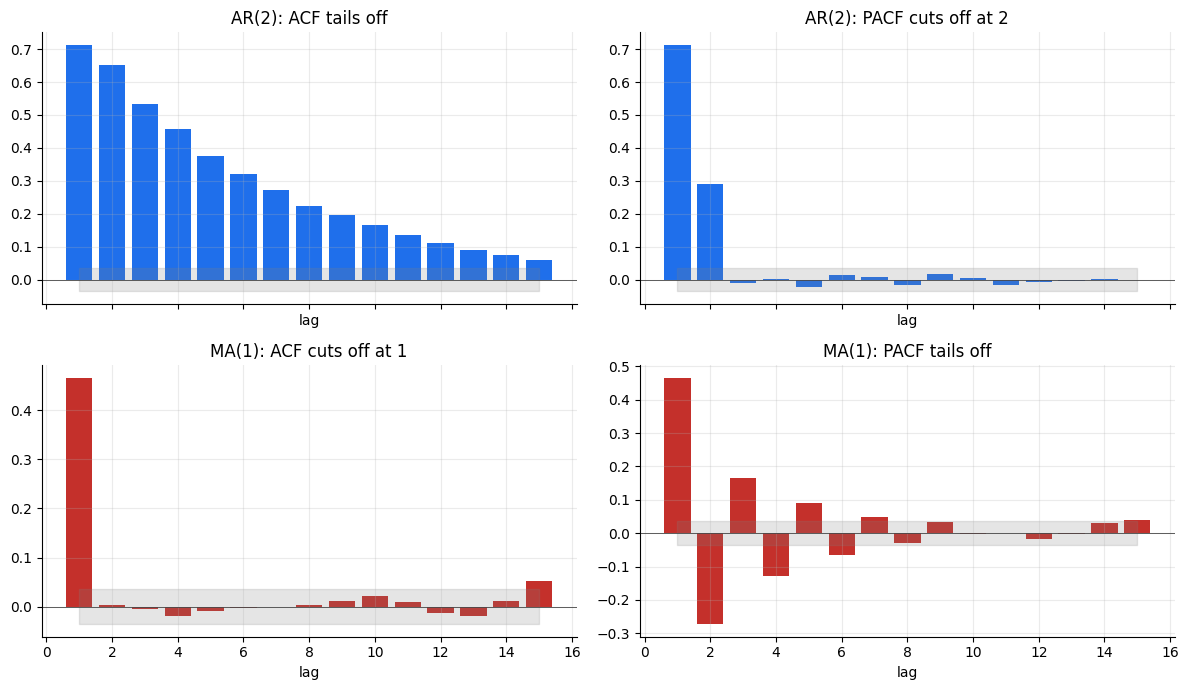

In [5]:
def sim_ar(phi, n, sigma=1.0, seed=0, burn=300):
    rng = np.random.default_rng(seed); p = len(phi)
    e = rng.normal(0, sigma, n + burn); y = np.zeros(n + burn)
    for t in range(p, n + burn):
        y[t] = e[t] + sum(phi[k] * y[t-1-k] for k in range(p))
    return y[burn:]

def sim_ma(theta, n, sigma=1.0, seed=0, burn=300):
    rng = np.random.default_rng(seed); q = len(theta)
    e = rng.normal(0, sigma, n + burn); y = np.zeros(n + burn)
    for t in range(q, n + burn):
        y[t] = e[t] + sum(theta[k] * e[t-1-k] for k in range(q))
    return y[burn:]

def sim_arma(phi, theta, n, sigma=1.0, seed=0, burn=300):
    rng = np.random.default_rng(seed); p = len(phi); q = len(theta)
    e = rng.normal(0, sigma, n + burn); y = np.zeros(n + burn)
    for t in range(max(p, q), n + burn):
        y[t] = (e[t] + sum(phi[k]*y[t-1-k] for k in range(p))
                + sum(theta[k]*e[t-1-k] for k in range(q)))
    return y[burn:]

ar2 = sim_ar([0.5, 0.3], 3000, seed=1)
ma1 = sim_ma([0.7], 3000, seed=2)

def plot_corr(ax, res, title, color):
    lags = np.arange(1, len(res.values) + 1)
    ax.bar(lags, res.values, color=color); ax.axhline(0, color='#444', lw=0.6)
    ax.fill_between(lags, res.lower_ci, res.upper_ci, color='gray', alpha=0.2)
    ax.set_title(title); ax.set_xlabel('lag')

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
plot_corr(axes[0, 0], acf(ar2, 15), 'AR(2): ACF tails off', '#1f6feb')
plot_corr(axes[0, 1], pacf(ar2, 15), 'AR(2): PACF cuts off at 2', '#1f6feb')
plot_corr(axes[1, 0], acf(ma1, 15), 'MA(1): ACF cuts off at 1', '#c4302b')
plot_corr(axes[1, 1], pacf(ma1, 15), 'MA(1): PACF tails off', '#c4302b')
plt.tight_layout(); plt.show()


## 3. Estimate — recover known parameters

The estimators earn trust the same way as before: simulate from *known*
coefficients, fit, and check we get them back. AR fits by Yule–Walker / OLS /
exact MLE; MA and ARMA by conditional-sum-of-squares or MLE (Kalman filter).


In [6]:
# AR(2): two estimators should agree with the truth.
TRUE_PHI = [0.5, 0.3]
ar_yw = AR(2).fit(ar2, method='yule_walker')
ar_mle = AR(2).fit(ar2, method='mle')
print(f'AR(2) true phi = {TRUE_PHI}')
print(f'  Yule-Walker  phi = {np.round(ar_yw.coef, 3).tolist()}   sigma2={ar_yw.sigma2:.3f}')
print(f'  MLE          phi = {np.round(ar_mle.coef, 3).tolist()}   sigma2={ar_mle.sigma2:.3f}')

# MA(1) and ARMA(1,1).
ma_fit = MA(1).fit(ma1, method='css')
arma_data = sim_arma([0.6], [-0.4], 4000, seed=3)
arma_fit = ARMA(1, 1).fit(arma_data, method='mle')
print(f'\nMA(1)   true theta = [0.7]        est = {np.round(ma_fit.coef, 3).tolist()}')
print(f'ARMA(1,1) true (phi, theta) = ([0.6], [-0.4])')
print(f'          est  phi={np.round(arma_fit.ar_coef,3).tolist()}  '
      f'theta={np.round(arma_fit.ma_coef,3).tolist()}')
print(f'\nAIC/BIC pick the order: AR(2) AIC={ar_mle.aic:.1f}, '
      f'AR(1) AIC={AR(1).fit(ar2, method="mle").aic:.1f}  (AR(2) wins)')


AR(2) true phi = [0.5, 0.3]
  Yule-Walker  phi = [0.505, 0.292]   sigma2=1.003
  MLE          phi = [0.505, 0.292]   sigma2=1.001



MA(1)   true theta = [0.7]        est = [0.694]
ARMA(1,1) true (phi, theta) = ([0.6], [-0.4])
          est  phi=[0.578]  theta=[-0.355]



AIC/BIC pick the order: AR(2) AIC=8520.3, AR(1) AIC=8787.4  (AR(2) wins)


## 4. A genuinely forecastable series — VIX

Most of finance is humbling here: **equity returns are essentially
unforecastable** by ARMA — their ACF is flat and the variance ratio sits at 1.
That is the efficient-market lesson, and it is worth *seeing* rather than
assuming.

But not every series is a random walk. **Volatility is persistent and
mean-reverting**, so `log(VIX)` has rich AR structure. We fit an AR model and
let it forecast the slow drift back toward the long-run mean — a real,
exploitable regularity.


In [7]:
# Returns: ARMA can't help. VIX: it can.
lb_ret = ljung_box(spy_ret, lags=10)
lb_vix = ljung_box(np.log(vix) - np.log(vix).mean(), lags=10)
print(f'Ljung-Box(10)  SPY returns : Q={lb_ret[0]:7.1f}  p={lb_ret[1]:.3f}  '
      '(little exploitable structure)')
print(f'Ljung-Box(10)  log-VIX     : Q={lb_vix[0]:7.1f}  p={lb_vix[1]:.2e}  '
      '(strongly autocorrelated)')

# Pick AR order on log-VIX by BIC (OLS fit — fast, identical information criteria).
scores = {p: AR(p).fit(log_vix, method='ols').bic for p in range(1, 9)}
best_p = min(scores, key=scores.get)
print(f'\nlog-VIX AR-order BIC scan: ' + '  '.join(f'p={p}:{b:.0f}' for p, b in scores.items()))
print(f'best AR order by BIC: p={best_p}')


Ljung-Box(10)  SPY returns : Q=   85.3  p=0.000  (little exploitable structure)
Ljung-Box(10)  log-VIX     : Q=35866.6  p=0.00e+00  (strongly autocorrelated)



log-VIX AR-order BIC scan: p=1:-9867  p=2:-9877  p=3:-9870  p=4:-9863  p=5:-9861  p=6:-9851  p=7:-9846  p=8:-9837
best AR order by BIC: p=2


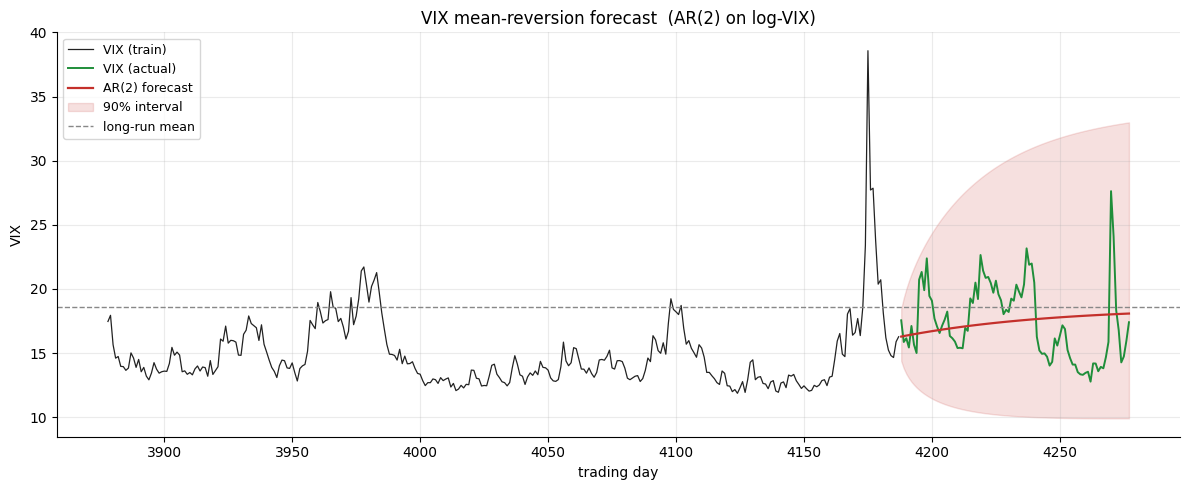

forecast RMSE on held-out VIX = 3.08 vol points


In [8]:
# Hold out the last 90 days; fit on the rest; forecast forward.
H = 90
train, test = log_vix[:-H], log_vix[-H:]
ar_model = AR(best_p)
ar = ar_model.fit(train, method='ols')
fc = ar_model.forecast(H, alpha=0.10)        # 90% interval

idx = np.arange(len(log_vix))
fig, ax = plt.subplots()
ax.plot(idx[-400:-H], np.exp(train[-(400-H):]), color='#222', lw=0.9, label='VIX (train)')
ax.plot(idx[-H:], np.exp(test), color='#1f8e3a', lw=1.4, label='VIX (actual)')
ax.plot(idx[-H:], np.exp(fc.mean), color='#c4302b', lw=1.6, label=f'AR({best_p}) forecast')
ax.fill_between(idx[-H:], np.exp(fc.lower), np.exp(fc.upper), color='#c4302b', alpha=0.15,
                label='90% interval')
ax.axhline(np.exp(ar.const), color='#888', ls='--', lw=1.0, label='long-run mean')
ax.set_title(f'VIX mean-reversion forecast  (AR({best_p}) on log-VIX)')
ax.set_ylabel('VIX'); ax.set_xlabel('trading day'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'forecast RMSE on held-out VIX = {rmse(np.exp(test), np.exp(fc.mean)):.2f} vol points')


## 5. ARIMA on a price level — forecasting through the difference

A price level needs $d=1$ differencing (it has a unit root). `ARIMA(p, 1, q)`
differences internally, fits ARMA on the returns, then **integrates the
forecast back** to the price scale. Because SPY returns are near-white,
the point forecast is essentially the random-walk-with-drift line — and the
honest message is in the **prediction interval**, which fans out like
$\sqrt{h}$ as uncertainty compounds.


ARIMA(1,1,1)  method=css  n_obs=4157
  drift   = 0.000401717
  phi[1]   = 0.122419
  theta[1]  = -0.227736
  sigma²   = 0.000159259
  log_lik  = 12278.9052
  AIC=-24549.8104  BIC=-24524.4802


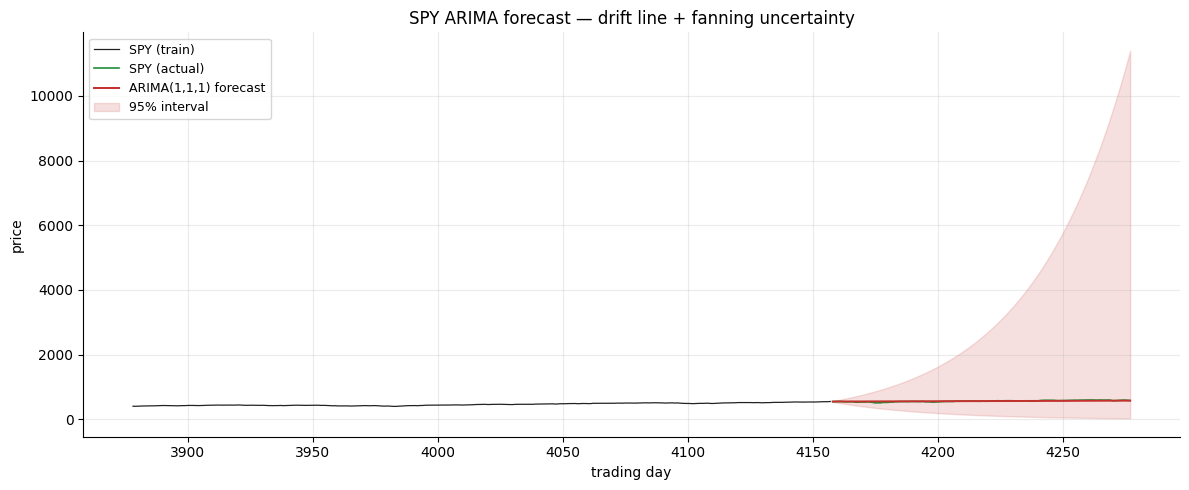

In [9]:
H = 120
log_spy = np.log(spy)
arima = ARIMA(1, 1, 1)
res = arima.fit(log_spy[:-H], method='css')
print(res)
fc = arima.forecast(H, alpha=0.05)

idx = np.arange(len(log_spy))
fig, ax = plt.subplots()
ax.plot(idx[-400:-H], np.exp(log_spy[-400:-H]), color='#222', lw=0.9, label='SPY (train)')
ax.plot(idx[-H:], np.exp(log_spy[-H:]), color='#1f8e3a', lw=1.2, label='SPY (actual)')
ax.plot(idx[-H:], np.exp(fc.mean), color='#c4302b', lw=1.4, label='ARIMA(1,1,1) forecast')
ax.fill_between(idx[-H:], np.exp(fc.lower), np.exp(fc.upper), color='#c4302b', alpha=0.15,
                label='95% interval')
ax.set_title('SPY ARIMA forecast — drift line + fanning uncertainty')
ax.set_ylabel('price'); ax.set_xlabel('trading day'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 6. SARIMA — seasonal structure

When a series repeats on a fixed period $s$ (monthly seasonality, weekly
intraday patterns), pure ARMA needs an unwieldy number of lags. **SARIMA** adds
compact seasonal AR/MA terms at lag $s$. We simulate a series with both a
short-lag AR component **and** a seasonal AR component at $s=12$, then recover it
with `SARIMA(1,0,0)(1,0,0)[12]` and forecast a full seasonal cycle ahead.


SARIMA(1,0,0)(1,0,0)[12]  method=css  n_obs=1164
  drift=0.0747933  sigma²=0.994985
  log_lik=-1650.7193  AIC=3309.4386  BIC=3329.6771


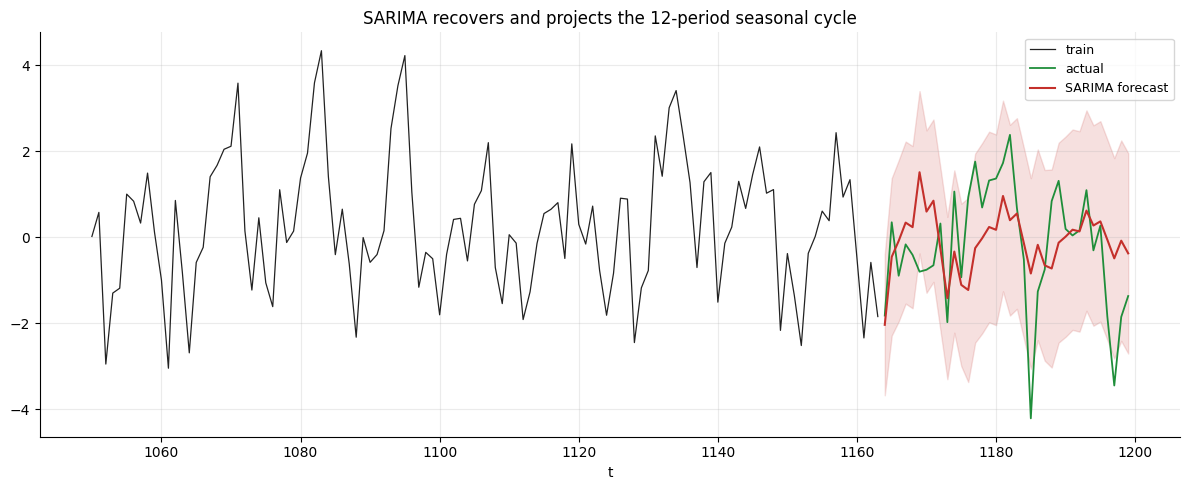

recovered: phi=[0.5]  seasonal Phi=[0.62]  (true 0.5 / 0.6)


In [10]:
# Seasonal AR: y_t = 0.5 y_{t-1} + 0.6 y_{t-12} - 0.30 y_{t-13} + e_t
# (the product (1-0.5 L)(1-0.6 L^12) expanded).
s = 12
rng = np.random.default_rng(11)
n = 1200
e = rng.normal(0, 1.0, n); y = np.zeros(n)
for t in range(13, n):
    y[t] = 0.5*y[t-1] + 0.6*y[t-12] - 0.30*y[t-13] + e[t]

H = 36
sar_model = SARIMA(1, 0, 0, 1, 0, 0, s)
sar = sar_model.fit(y[:-H], method='css')
print(sar)
fc = sar_model.forecast(H, alpha=0.10)

idx = np.arange(n)
fig, ax = plt.subplots()
ax.plot(idx[-150:-H], y[-150:-H], color='#222', lw=0.9, label='train')
ax.plot(idx[-H:], y[-H:], color='#1f8e3a', lw=1.3, label='actual')
ax.plot(idx[-H:], fc.mean, color='#c4302b', lw=1.5, label='SARIMA forecast')
ax.fill_between(idx[-H:], fc.lower, fc.upper, color='#c4302b', alpha=0.15)
ax.set_title('SARIMA recovers and projects the 12-period seasonal cycle')
ax.set_xlabel('t'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'recovered: phi={np.round(sar.ar_coef,2).tolist()}  '
      f'seasonal Phi={np.round(sar.seasonal_ar_coef,2).tolist()}  (true 0.5 / 0.6)')


## 7. Diagnose & evaluate

A model is only trustworthy if its **residuals are white noise** (Ljung–Box
fails to reject) and — the real test — it **beats a naive benchmark
out-of-sample**. We:

1. Check the VIX-model residuals with Ljung–Box and Jarque–Bera.
2. Run a **walk-forward `RollingBacktest`** of AR(1) vs a mean baseline on VIX.
3. Settle it with the **Diebold–Mariano** test for equal predictive accuracy.


In [11]:
resid = ar.residuals
lb = ljung_box(resid, lags=20, dof_adjust=best_p)
jb = jarque_bera(resid)
print(f'AR({best_p}) residual diagnostics:')
print(f'  Ljung-Box(20)  Q={lb[0]:.1f}  p={lb[1]:.3f}  -> '
      f'{"white noise (good)" if lb[1] > 0.05 else "structure remains"}')
print(f'  Jarque-Bera    JB={jb[0]:.1f}  p={jb[1]:.2e}  (fat tails are expected for vol)')


AR(2) residual diagnostics:
  Ljung-Box(20)  Q=31.0  p=0.028  -> structure remains
  Jarque-Bera    JB=9298.8  p=0.00e+00  (fat tails are expected for vol)


In [12]:
class MeanModel:
    """Naive baseline: forecast = training mean."""
    def fit(self, y):
        self.mu = float(np.mean(y)); return self
    def forecast(self, h):
        return np.full(h, self.mu)

bt_ar = RollingBacktest(lambda: AR(1), window=500, refit_every=5, h=1).run(log_vix)
bt_mean = RollingBacktest(lambda: MeanModel(), window=500, refit_every=5, h=1).run(log_vix)
print(f'Walk-forward 1-step RMSE on log-VIX  ({bt_ar.n_windows} windows):')
print(f'  AR(1)        RMSE={bt_ar.rmse:.4f}')
print(f'  Mean (naive) RMSE={bt_mean.rmse:.4f}')

dm = diebold_mariano(bt_ar.errors[:, 0], bt_mean.errors[:, 0], h=1, loss='squared')
verdict = ('AR(1) significantly better' if dm.stat < 0 and dm.p_value < 0.05
           else 'no significant difference')
print(f'\nDiebold-Mariano: stat={dm.stat:+.2f}  p={dm.p_value:.2e}  ->  {verdict}')
print('(stat < 0 means the first model, AR(1), has the lower loss.)')


Walk-forward 1-step RMSE on log-VIX  (756 windows):
  AR(1)        RMSE=0.0815
  Mean (naive) RMSE=0.3032

Diebold-Mariano: stat=-14.26  p=3.79e-46  ->  AR(1) significantly better
(stat < 0 means the first model, AR(1), has the lower loss.)


## What next?

* **Auto-order selection.** Wrap the AIC/BIC scan into a grid over
  $(p,d,q)$ to automate Box–Jenkins identification.
* **Heteroskedastic errors.** ARMA models the *mean*; pair it with a
  **GARCH** error model (`qufin.timeseries.garch`) — the squared residuals here
  are clearly autocorrelated. See the GARCH volatility tutorial.
* **Multivariate.** When several series co-move, graduate to **VAR** and
  cointegration (`qufin.timeseries.var` / `.cointegration`).
* **State space.** `ARMAStateSpace` exposes the Kalman filter / RTS smoother
  directly for missing-data handling and time-varying parameters.
